# 1. Import Libraries

In [1]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Load Data

In [2]:
students_df = pd.read_csv("StudentsPerformance.csv")
print(students_df.head())
print(students_df.info())
print(students_df.describe())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

# 3. Exploratory Data Analysis

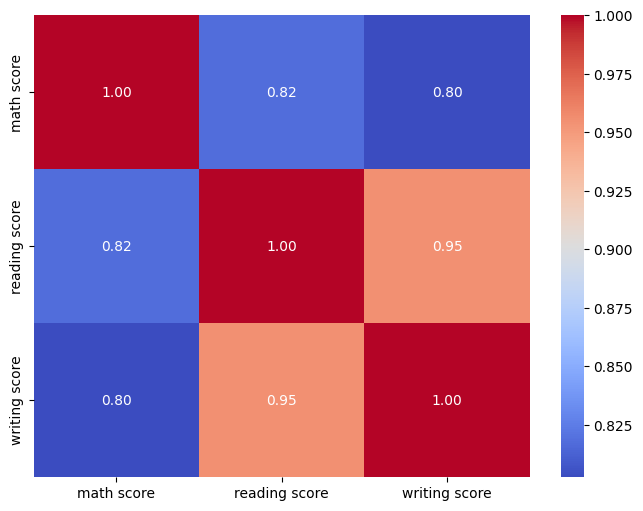

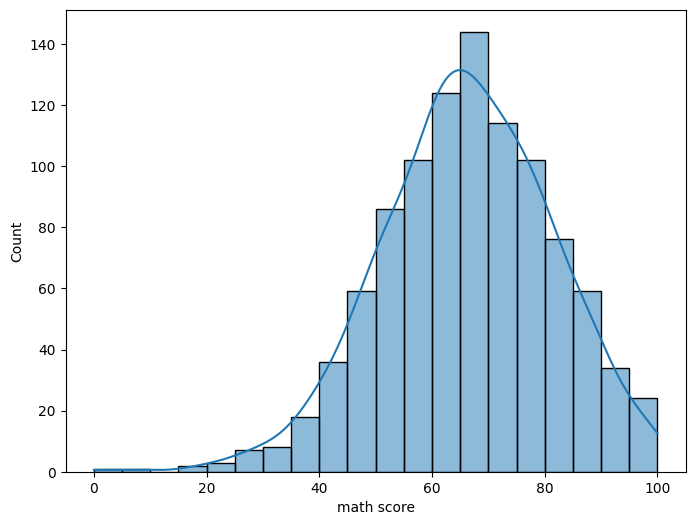

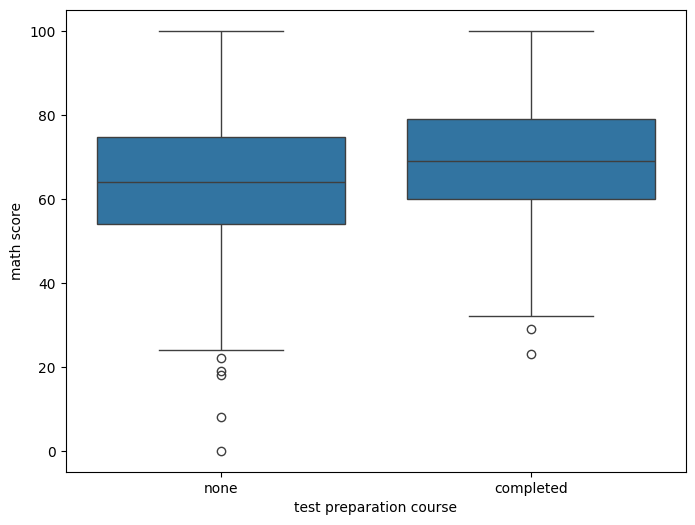

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(students_df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(students_df['math score'], bins=20, kde=True)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='test preparation course', y='math score', data=students_df)
plt.show()

# 4. Data Cleaning

In [4]:
missing_values = students_df.isnull().sum()
print(missing_values)

duplicate_count = students_df.duplicated().sum()
print(duplicate_count)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
0


# 5. Feature Engineering

In [5]:
students_df['average_score'] = (students_df['math score'] + students_df['reading score'] + students_df['writing score']) / 3
print(students_df.head())


   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   average_score  
0      72.666667  
1      82.333333  
2      92.666667  
3      49.333333  
4      76.333333  


# 6. Train-Test Split

In [6]:
X = students_df.drop(columns=['math score', 'reading score', 'writing score', 'average_score'])
y_math = students_df['math score']
y_reading = students_df['reading score']
y_writing = students_df['writing score']
y_average = students_df['average_score']

targets = {
    'math': y_math,
    'reading': y_reading,
    'writing': y_writing,
    'average': y_average
}

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

y_train = {}
y_test = {}
for name, y in targets.items():
    ytrain, ytest = train_test_split(y, test_size=0.2, random_state=42)
    y_train[name] = ytrain
    y_test[name] = ytest


# 7. Train Models

In [7]:
def train_models_tuned(X_train, y_train_dict):
    categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
    numeric_features = []
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), categorical_features)
        ])
    
    models_config = {
        'Linear Regression': {
            'model': LinearRegression(),
            'params': {}
        },
        'Decision Tree': {
            'model': DecisionTreeRegressor(random_state=42),
            'params': {
                'regressor__max_depth': [3, 5, 10, None],
                'regressor__min_samples_split': [2, 5, 10],
                'regressor__min_samples_leaf': [1, 2, 4]
            }
        },
        'Random Forest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'regressor__n_estimators': [50, 100],
                'regressor__max_depth': [5, 10, None],
                'regressor__max_features': ['sqrt', 'log2', None],
                'regressor__min_samples_split': [2, 5]
            }
        }
    }
    
    trained_models = {}
    for target_name, y in y_train_dict.items():
        print(f"Tuning models for {target_name}...")
        trained_models[target_name] = {}
        for m_name, config in models_config.items():
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('regressor', config['model'])
            ])
            grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='r2', n_jobs=-1)
            grid.fit(X_train, y)
            trained_models[target_name][m_name] = grid
            print(f"  {m_name} best CV R2: {grid.best_score_:.4f}")
    return trained_models

trained_models = train_models_tuned(X_train, y_train)


Tuning models for math...


  Linear Regression best CV R2: 0.2392


  Decision Tree best CV R2: 0.1604


  Random Forest best CV R2: 0.2016
Tuning models for reading...
  Linear Regression best CV R2: 0.2122


  Decision Tree best CV R2: 0.1597


  Random Forest best CV R2: 0.1816
Tuning models for writing...
  Linear Regression best CV R2: 0.3196


  Decision Tree best CV R2: 0.2527


  Random Forest best CV R2: 0.2862
Tuning models for average...
  Linear Regression best CV R2: 0.2283


  Decision Tree best CV R2: 0.1785


  Random Forest best CV R2: 0.1954


# 8. Evaluate and Compare

In [8]:
def evaluate_models_cv(models_dict, X_test, y_test_dict):
    results = []
    for target_name, models in models_dict.items():
        y_test_target = y_test_dict[target_name]
        
        for m_name, grid in models.items():
            # CV on train data from GridSearchCV
            mean_cv_r2 = grid.best_score_
            std_cv_r2 = grid.cv_results_['std_test_score'][grid.best_index_]
            
            # Evaluation on test data
            y_pred = grid.predict(X_test)
            mae = mean_absolute_error(y_test_target, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test_target, y_pred))
            test_r2 = r2_score(y_test_target, y_pred)
            
            results.append({
                'Target': target_name,
                'Model': m_name,
                'CV Mean R2': mean_cv_r2,
                'CV Std R2': std_cv_r2,
                'Test MAE': mae,
                'Test RMSE': rmse,
                'Test R2': test_r2,
                'Best Params': grid.best_params_
            })
    return pd.DataFrame(results)

evaluation_results = evaluate_models_cv(trained_models, X_test, y_test)
print("Evaluation Results:\n")
print(evaluation_results.drop(columns=['Best Params']).to_string())


Evaluation Results:

     Target              Model  CV Mean R2  CV Std R2   Test MAE  Test RMSE   Test R2
0      math  Linear Regression    0.239220   0.081065  11.269874  14.160187  0.176000
1      math      Decision Tree    0.160392   0.049263  11.871321  15.063856  0.067472
2      math      Random Forest    0.201632   0.071242  11.446099  14.501099  0.135846
3   reading  Linear Regression    0.212222   0.042234  10.830288  13.791864  0.159396
4   reading      Decision Tree    0.159675   0.032679  11.267762  14.260398  0.101313
5   reading      Random Forest    0.181578   0.044637  11.068731  14.063311  0.125982
6   writing  Linear Regression    0.319554   0.057407  10.193143  13.321117  0.263736
7   writing      Decision Tree    0.252654   0.044514  10.977028  14.293675  0.152304
8   writing      Random Forest    0.286188   0.041023  10.455586  13.765786  0.213761
9   average  Linear Regression    0.228256   0.058546  10.490183  13.401581  0.162172
10  average      Decision Tree   

# 9. Feature Importance

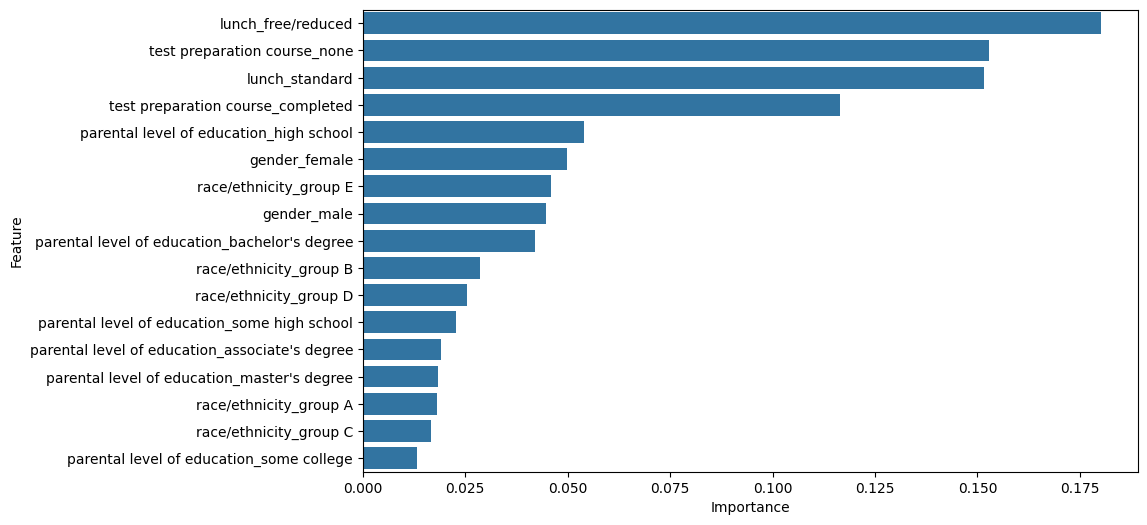

In [9]:
rf_grid = trained_models['average']['Random Forest']
best_rf_pipeline = rf_grid.best_estimator_

# Extract feature names from preprocessor
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
preprocessor = best_rf_pipeline.named_steps['preprocessor']
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
features = list(ohe_feature_names)

# Extract importance from regressor
rf_model = best_rf_pipeline.named_steps['regressor']
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({"Feature": features, "Importance": importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.show()


# 10. Best Model Selection

In [10]:
def get_best_models(results_df):
    best_models_info = {}
    for target in results_df['Target'].unique():
        target_results = results_df[results_df['Target'] == target]
        # We use Test R2 for selecting the final best model to save
        best_row = target_results.loc[target_results['Test R2'].idxmax()]
        best_models_info[target] = {
            'Model': best_row['Model'],
            'Test R2': best_row['Test R2'],
            'Test RMSE': best_row['Test RMSE'],
            'Best Params': best_row['Best Params']
        }
        print(f"Best model for {target.capitalize()} Score: {best_row['Model']} with Test R2 = {best_row['Test R2']:.4f}, Test RMSE = {best_row['Test RMSE']:.4f}")
        print(f"  Params: {best_row['Best Params']}")
    return best_models_info

best_models_info = get_best_models(evaluation_results)


Best model for Math Score: Linear Regression with Test R2 = 0.1760, Test RMSE = 14.1602
  Params: {}
Best model for Reading Score: Linear Regression with Test R2 = 0.1594, Test RMSE = 13.7919
  Params: {}
Best model for Writing Score: Linear Regression with Test R2 = 0.2637, Test RMSE = 13.3211
  Params: {}
Best model for Average Score: Linear Regression with Test R2 = 0.1622, Test RMSE = 13.4016
  Params: {}


# 11. Save Best Models

In [11]:
os.makedirs('models', exist_ok=True)

for target, info in best_models_info.items():
    best_model_name = info['Model']
    # Save the pipeline directly
    best_pipeline = trained_models[target][best_model_name].best_estimator_
    joblib.dump(best_pipeline, f'models/{target}_score_model.joblib')
    print(f"Saved {best_model_name} for {target} to models/{target}_score_model.joblib")


Saved Linear Regression for math to models/math_score_model.joblib
Saved Linear Regression for reading to models/reading_score_model.joblib
Saved Linear Regression for writing to models/writing_score_model.joblib
Saved Linear Regression for average to models/average_score_model.joblib
